In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Store the final evaluation metrics for both models.

comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Multinomial Logistic Regression"
    ],
    "Accuracy": [
        0.8207666666666666,
        0.8605
    ],
    "Precision": [
        0.8245150374603653,
        0.8602100892571779
    ],
    "Recall": [
        0.8207666666666666,
        0.8605
    ],
    "F1_Score": [
        0.8218401806556178,
        0.8603379350207826
    ]
})

comparison


,Model,Accuracy,Precision,Recall,F1_Score
0,Multinomial Naive Bayes,0.820767,0.824515,0.820767,0.821840
1,Multinomial Logistic Regression,0.860500,0.860210,0.860500,0.860338


In [4]:
# Save the model comparison results.

comparison.to_csv(
     "../results/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [5]:
# Convert the comparison DataFrame from wide format to long format.

comparison_long = comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

comparison_long

,Model,Metric,Score
0,Multinomial Naive Bayes,Accuracy,0.820767
1,Multinomial Logistic Regression,Accuracy,0.860500
2,Multinomial Naive Bayes,Precision,0.824515
3,Multinomial Logistic Regression,Precision,0.860210
4,Multinomial Naive Bayes,Recall,0.820767
5,Multinomial Logistic Regression,Recall,0.860500
6,Multinomial Naive Bayes,F1_Score,0.821840
7,Multinomial Logistic Regression,F1_Score,0.860338


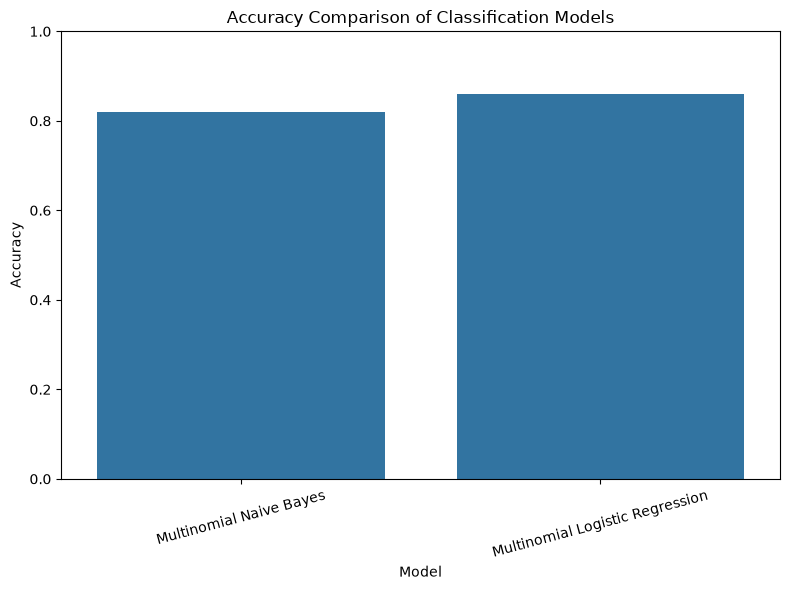

In [6]:
# Compare the accuracy of both models.

plt.figure(figsize=(8, 6))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Accuracy Comparison of Classification Models"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Accuracy"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.savefig(
     "../images/accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

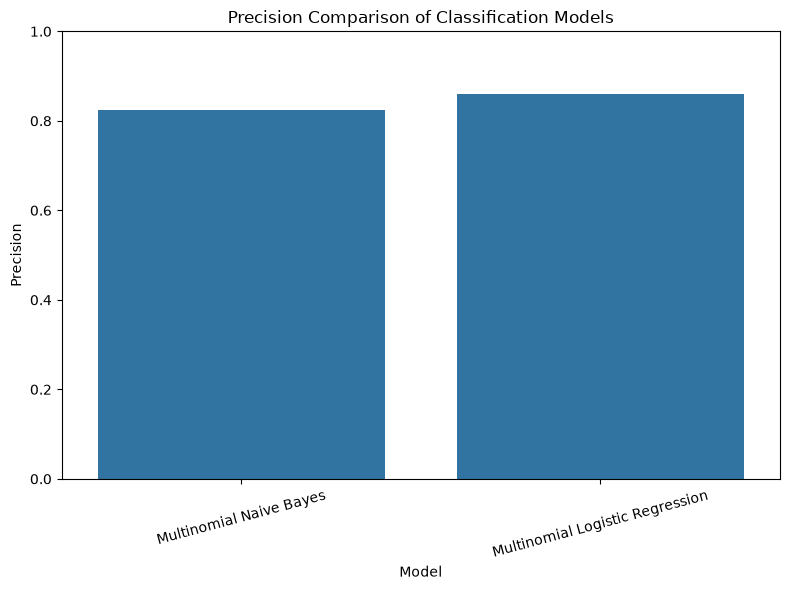

In [7]:
# Compare precision between the two models.

plt.figure(figsize=(8, 6))

sns.barplot(
    data=comparison,
    x="Model",
    y="Precision"
)

plt.title(
    "Precision Comparison of Classification Models"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Precision"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.savefig(
     "../images/precision_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

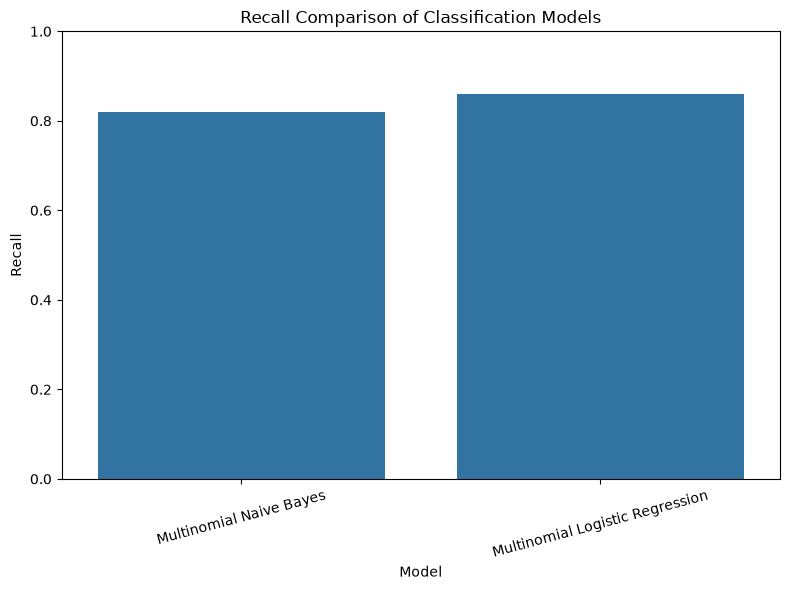

In [8]:
# Compare recall between the two models.

plt.figure(figsize=(8, 6))

sns.barplot(
    data=comparison,
    x="Model",
    y="Recall"
)

plt.title(
    "Recall Comparison of Classification Models"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Recall"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.savefig(
     "../images/recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

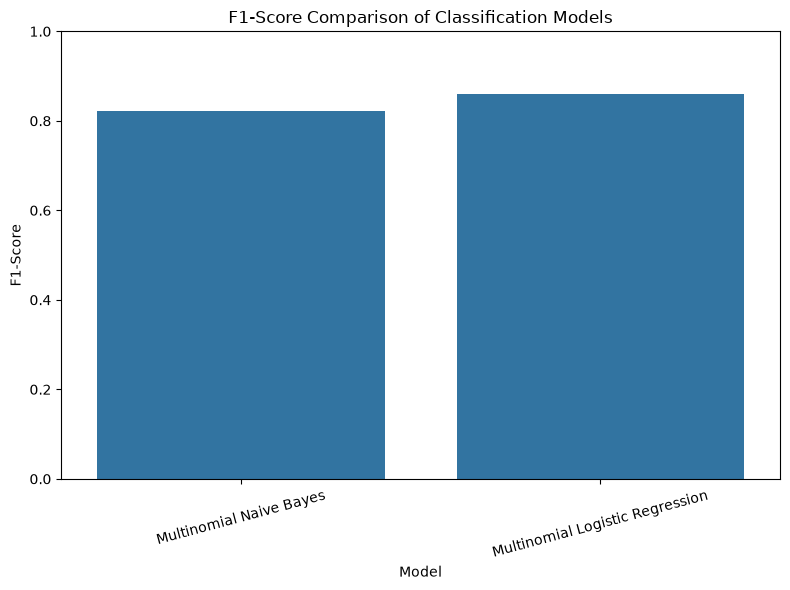

In [10]:
# Compare F1-score between the two models.

plt.figure(figsize=(8, 6))

sns.barplot(
    data=comparison,
    x="Model",
    y="F1_Score"
)

plt.title(
    "F1-Score Comparison of Classification Models"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "F1-Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.savefig(
     "../images/f1_score_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

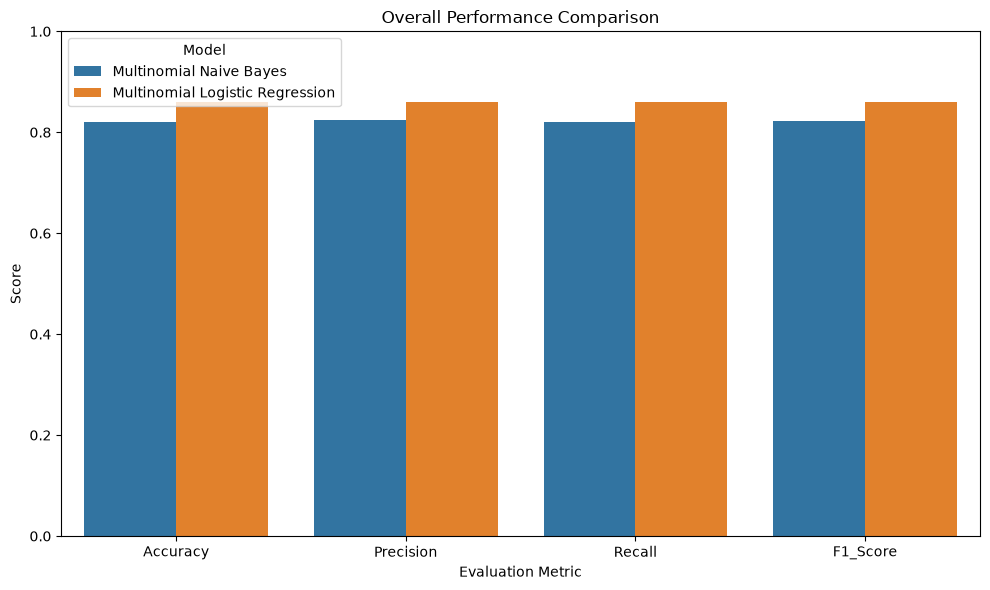

In [11]:
# Plot all evaluation metrics for both models.

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title(
    "Overall Performance Comparison"
)

plt.xlabel(
    "Evaluation Metric"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.tight_layout()

plt.savefig(
     "../images/overall_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# Calculate the improvement of Logistic Regression
# over Multinomial Naive Bayes.

nb_metrics = comparison.iloc[0]

lr_metrics = comparison.iloc[1]

improvement = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score"
    ],
    "Naive_Bayes": [
        nb_metrics["Accuracy"],
        nb_metrics["Precision"],
        nb_metrics["Recall"],
        nb_metrics["F1_Score"]
    ],
    "Logistic_Regression": [
        lr_metrics["Accuracy"],
        lr_metrics["Precision"],
        lr_metrics["Recall"],
        lr_metrics["F1_Score"]
    ]
})

improvement["Absolute_Improvement"] = (
    improvement["Logistic_Regression"]
    - improvement["Naive_Bayes"]
)

improvement["Percentage_Point_Improvement"] = (
    improvement["Absolute_Improvement"] * 100
)

improvement

,Metric,Naive_Bayes,Logistic_Regression,Absolute_Improvement,Percentage_Point_Improvement
0,Accuracy,0.820767,0.860500,0.039733,3.973333
1,Precision,0.824515,0.860210,0.035695,3.569505
2,Recall,0.820767,0.860500,0.039733,3.973333
3,F1_Score,0.821840,0.860338,0.038498,3.849775


In [13]:
# Display the improvement in an easy-to-read format.

print("Improvement of Logistic Regression over Naive Bayes")

for _, row in improvement.iterrows():

    print(
        f"{row['Metric']}: "
        f"{row['Percentage_Point_Improvement']:.2f} percentage points"
    )

Improvement of Logistic Regression over Naive Bayes
Accuracy: 3.97 percentage points
Precision: 3.57 percentage points
Recall: 3.97 percentage points
F1_Score: 3.85 percentage points


In [14]:
# Store class-level performance for both models.

class_performance = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Naive Bayes",
        "Naive Bayes",
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression"
    ],
    "Sentiment": [
        "Negative",
        "Neutral",
        "Positive",
        "Negative",
        "Neutral",
        "Positive"
    ],
    "Precision": [
        0.84,
        0.74,
        0.89,
        0.89,
        0.81,
        0.88
    ],
    "Recall": [
        0.85,
        0.80,
        0.82,
        0.90,
        0.80,
        0.88
    ],
    "F1_Score": [
        0.84,
        0.77,
        0.85,
        0.89,
        0.81,
        0.88
    ]
})

class_performance

,Model,Sentiment,Precision,Recall,F1_Score
0,Naive Bayes,Negative,0.84,0.85,0.84
1,Naive Bayes,Neutral,0.74,0.80,0.77
2,Naive Bayes,Positive,0.89,0.82,0.85
3,Logistic Regression,Negative,0.89,0.90,0.89
4,Logistic Regression,Neutral,0.81,0.80,0.81
5,Logistic Regression,Positive,0.88,0.88,0.88


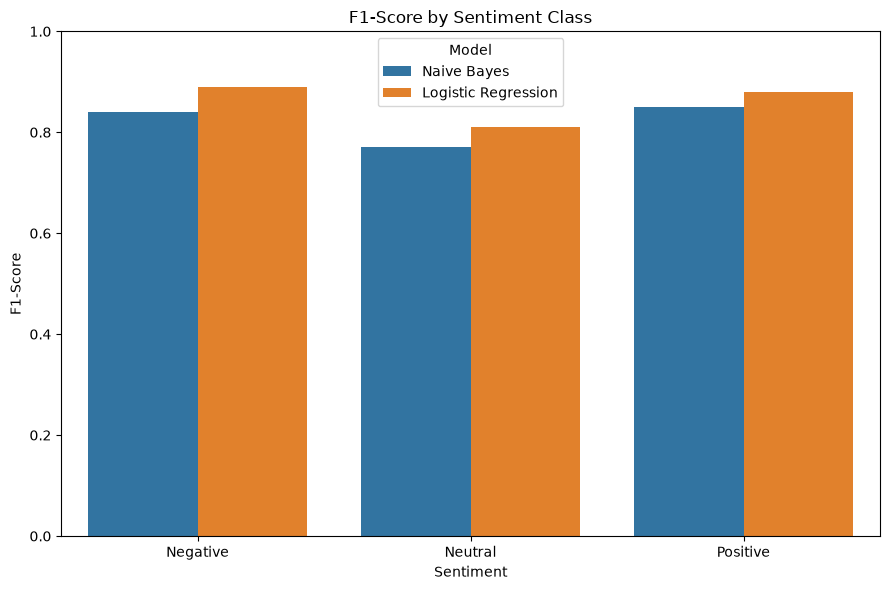

In [15]:
# Compare F1-score for each sentiment class.

plt.figure(figsize=(9, 6))

sns.barplot(
    data=class_performance,
    x="Sentiment",
    y="F1_Score",
    hue="Model"
)

plt.title(
    "F1-Score by Sentiment Class"
)

plt.xlabel(
    "Sentiment"
)

plt.ylabel(
    "F1-Score"
)

plt.ylim(
    0,
    1
)

plt.tight_layout()

plt.savefig(
     "../images/class_level_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# Identify the best-performing model based on F1-score.

best_model = comparison.loc[
    comparison["F1_Score"].idxmax()
]

print("Best Model:")
print(best_model["Model"])

print(
    "\nBest F1-Score:",
    best_model["F1_Score"]
)

print(
    "Best Accuracy:",
    best_model["Accuracy"]
)

Best Model:
Multinomial Logistic Regression

Best F1-Score: 0.8603379350207826
Best Accuracy: 0.8605


In [17]:
# Define the class labels in the same order used by the confusion matrices.

labels = [
    "Negative",
    "Neutral",
    "Positive"
]

# Confusion matrix for Multinomial Naive Bayes.
# Rows represent actual classes.
# Columns represent predicted classes.

cm_nb = np.array([
    [8451, 1426, 123],
    [1126, 7971, 903],
    [440, 1359, 8201]
])

# Confusion matrix for Multinomial Logistic Regression.

cm_lr = np.array([
    [8982, 850, 168],
    [899, 8042, 1059],
    [219, 990, 8791]
])

print("Naive Bayes Confusion Matrix:")
print(cm_nb)

print("\nLogistic Regression Confusion Matrix:")
print(cm_lr)

Naive Bayes Confusion Matrix:
[[8451 1426  123]
 [1126 7971  903]
 [ 440 1359 8201]]

Logistic Regression Confusion Matrix:
[[8982  850  168]
 [ 899 8042 1059]
 [ 219  990 8791]]


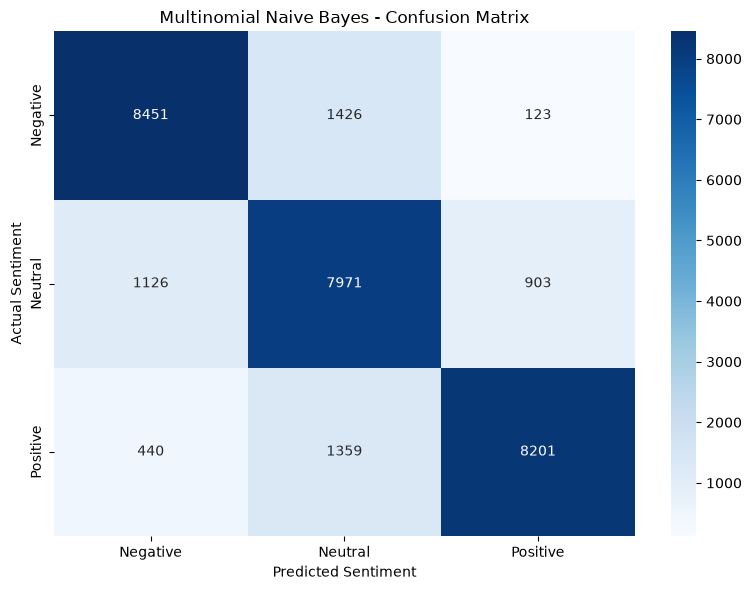

In [18]:
# Plot the confusion matrix for Multinomial Naive Bayes.

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "Multinomial Naive Bayes - Confusion Matrix"
)

plt.xlabel(
    "Predicted Sentiment"
)

plt.ylabel(
    "Actual Sentiment"
)

plt.tight_layout()

plt.savefig(
    "../images/naive_bayes_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

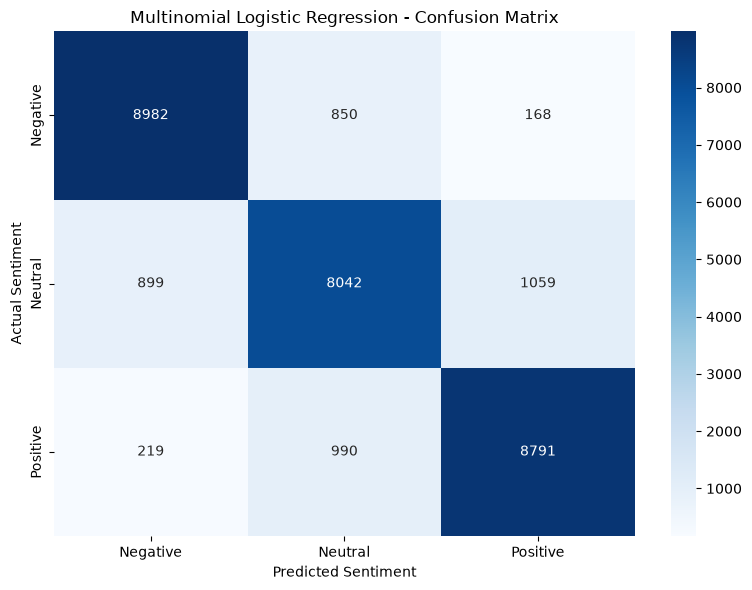

In [19]:
# Plot the confusion matrix for Multinomial Logistic Regression.

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "Multinomial Logistic Regression - Confusion Matrix"
)

plt.xlabel(
    "Predicted Sentiment"
)

plt.ylabel(
    "Actual Sentiment"
)

plt.tight_layout()

plt.savefig(
    "../images/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

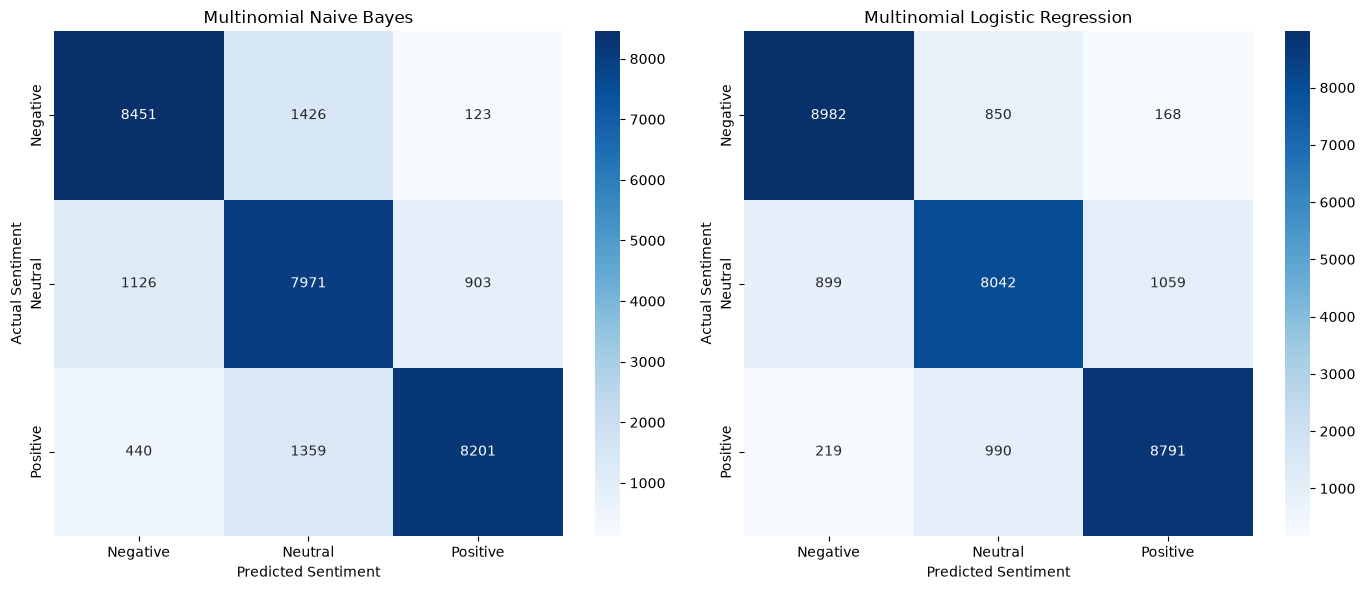

In [21]:
# Display both confusion matrices side-by-side.

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# Naive Bayes

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_title(
    "Multinomial Naive Bayes"
)

axes[0].set_xlabel(
    "Predicted Sentiment"
)

axes[0].set_ylabel(
    "Actual Sentiment"
)


# Logistic Regression

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_title(
    "Multinomial Logistic Regression"
)

axes[1].set_xlabel(
    "Predicted Sentiment"
)

axes[1].set_ylabel(
    "Actual Sentiment"
)

plt.tight_layout()

plt.savefig(
    "../images/confusion_matrix_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# Calculate the total number of incorrect predictions
# for each model.

nb_correct = np.trace(cm_nb)

lr_correct = np.trace(cm_lr)

nb_total = cm_nb.sum()

lr_total = cm_lr.sum()

nb_errors = nb_total - nb_correct

lr_errors = lr_total - lr_correct

print("Naive Bayes")
print("-----------")
print("Correct predictions:", nb_correct)
print("Incorrect predictions:", nb_errors)

print("\nLogistic Regression")
print("-------------------")
print("Correct predictions:", lr_correct)
print("Incorrect predictions:", lr_errors)

Naive Bayes
-----------
Correct predictions: 24623
Incorrect predictions: 5377

Logistic Regression
-------------------
Correct predictions: 25815
Incorrect predictions: 4185


In [23]:
# Create a detailed table showing misclassification counts.

error_analysis = pd.DataFrame({
    "Actual Class": [
        "Negative",
        "Negative",
        "Neutral",
        "Neutral",
        "Positive",
        "Positive"
    ],
    "Predicted Class": [
        "Neutral",
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Neutral"
    ],
    "Naive Bayes Errors": [
        cm_nb[0, 1],
        cm_nb[0, 2],
        cm_nb[1, 0],
        cm_nb[1, 2],
        cm_nb[2, 0],
        cm_nb[2, 1]
    ],
    "Logistic Regression Errors": [
        cm_lr[0, 1],
        cm_lr[0, 2],
        cm_lr[1, 0],
        cm_lr[1, 2],
        cm_lr[2, 0],
        cm_lr[2, 1]
    ]
})

# Calculate the reduction in errors.

error_analysis["Error Reduction"] = (
    error_analysis["Naive Bayes Errors"]
    - error_analysis["Logistic Regression Errors"]
)

error_analysis

,Actual Class,Predicted Class,Naive Bayes Errors,Logistic Regression Errors,Error Reduction
0,Negative,Neutral,1426,850,576
1,Negative,Positive,123,168,-45
2,Neutral,Negative,1126,899,227
3,Neutral,Positive,903,1059,-156
4,Positive,Negative,440,219,221
5,Positive,Neutral,1359,990,369


In [26]:
# Display the error analysis in a readable format.

print("Detailed Error Analysis")
print("="*23)

for _, row in error_analysis.iterrows():

    print(
        f"Actual: {row['Actual Class']} "
        f"→ Predicted: {row['Predicted Class']}"
    )

    print(
        f"Naive Bayes Errors: "
        f"{row['Naive Bayes Errors']}"
    )

    print(
        f"Logistic Regression Errors: "
        f"{row['Logistic Regression Errors']}"
    )

    print(
        f"Error Reduction: "
        f"{row['Error Reduction']}"
    )

    print()

Detailed Error Analysis
Actual: Negative → Predicted: Neutral
Naive Bayes Errors: 1426
Logistic Regression Errors: 850
Error Reduction: 576

Actual: Negative → Predicted: Positive
Naive Bayes Errors: 123
Logistic Regression Errors: 168
Error Reduction: -45

Actual: Neutral → Predicted: Negative
Naive Bayes Errors: 1126
Logistic Regression Errors: 899
Error Reduction: 227

Actual: Neutral → Predicted: Positive
Naive Bayes Errors: 903
Logistic Regression Errors: 1059
Error Reduction: -156

Actual: Positive → Predicted: Negative
Naive Bayes Errors: 440
Logistic Regression Errors: 219
Error Reduction: 221

Actual: Positive → Predicted: Neutral
Naive Bayes Errors: 1359
Logistic Regression Errors: 990
Error Reduction: 369



In [30]:
# Identify the largest sources of classification errors
# for each model.

nb_largest_error = error_analysis.loc[
    error_analysis["Naive Bayes Errors"].idxmax()
]

lr_largest_error = error_analysis.loc[
    error_analysis["Logistic Regression Errors"].idxmax()
]

print("Largest Naive Bayes Error Category")
print("-"*34)

print(
    nb_largest_error[
        [
            "Actual Class",
            "Predicted Class",
            "Naive Bayes Errors"
        ]
    ]
)

print("\nLargest Logistic Regression Error Category")
print("-"*42)

print(
    lr_largest_error[
        [
            "Actual Class",
            "Predicted Class",
            "Logistic Regression Errors"
        ]
    ]
)

Largest Naive Bayes Error Category
----------------------------------
Actual Class          Negative
Predicted Class        Neutral
Naive Bayes Errors        1426
Name: 0, dtype: object

Largest Logistic Regression Error Category
------------------------------------------
Actual Class                   Neutral
Predicted Class               Positive
Logistic Regression Errors        1059
Name: 3, dtype: object


In [31]:
# Calculate how many fewer errors Logistic Regression makes
# compared with Naive Bayes.

total_error_reduction = (
    nb_errors - lr_errors
)

error_reduction_percentage = (
    total_error_reduction / nb_errors
) * 100

print(
    "Total error reduction:",
    total_error_reduction
)

print(
    "Percentage reduction in errors:",
    round(
        error_reduction_percentage,
        2
    ),
    "%"
)

Total error reduction: 1192
Percentage reduction in errors: 22.17 %


In [32]:
# Save the detailed error analysis table.

error_analysis.to_csv(
    "../results/error_analysis.csv",
    index=False
)

print(
    "Error analysis saved successfully."
)

Error analysis saved successfully.


## Final Conclusion

This project implemented a complete classical NLP sentiment classification pipeline using a balanced subset of the Yelp Review Dataset.

The dataset was filtered to retain 1-star, 3-star, and 5-star reviews, which were mapped to Negative, Neutral, and Positive sentiment classes respectively. A balanced dataset containing 50,000 reviews from each class was then created.

The review text was cleaned and preprocessed before being converted into numerical features using TF-IDF. Two classification algorithms were then trained and evaluated: Multinomial Naive Bayes and Multinomial Logistic Regression.

Multinomial Naive Bayes achieved an accuracy of 82.08% and a weighted F1-score of 82.18%.

Multinomial Logistic Regression achieved an accuracy of 86.05% and a weighted F1-score of 86.03%.

Therefore, Logistic Regression outperformed Naive Bayes across all major evaluation metrics.

The confusion matrix analysis showed that Neutral and Positive reviews were the most difficult classes to distinguish. Logistic Regression reduced the total number of classification errors from 5,377 to 4,185, resulting in 1,192 fewer errors than Naive Bayes.

Overall, Multinomial Logistic Regression was the better-performing model for this dataset. However, the results also demonstrate that traditional machine learning models still have difficulty understanding the more subtle boundaries between sentiment categories, particularly when a review contains mixed or ambiguous opinions.

This project provided practical experience with text preprocessing, negation handling, TF-IDF vectorization, classical NLP classification, model evaluation, confusion matrix analysis, and error analysis.